# Industrial Surface Defect Detection Using Deep Learning and Explainable AI
## Milestone 1 — MVTec Tile Dataset Validation, EDA, and Leakage-Safe Splitting

**Primary task:** Supervised binary classification (`good` vs. `defective`)  
**Dataset:** MVTec AD — Tile category  
**Target split:** 70% training / 15% validation / 15% test  
**Random seed:** 42

This notebook validates the raw dataset, builds auditable image metadata, detects exact and perceptually similar images, and creates reproducible file-level splits without modifying or copying raw images.

> MVTec AD was designed for unsupervised anomaly detection: its official training set contains only good images. For this approved supervised project, all source images are pooled and re-split. Results from this protocol must not be presented as directly comparable with the official MVTec AD benchmark.

## 1. Methodology and safeguards

- Raw images and ground-truth masks remain unchanged.
- Ground-truth masks are excluded from classification inputs.
- Exact duplicates are detected using SHA-256.
- Near-duplicates are screened using two 256-bit perceptual hashes.
- Connected near-duplicate candidates are assigned to the same split.
- Splitting is stratified by detailed defect type.
- The test split is reserved for final evaluation only.
- Augmentation will be applied later and only to the training split.

In [6]:
from __future__ import annotations

import hashlib
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, UnidentifiedImageError

SEED = 42
SPLIT_RATIOS = {"train": 0.70, "validation": 0.15, "test": 0.15}
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "mvtec_ad" / "tile"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "tile"
MANIFEST_DIR = PROCESSED_ROOT / "manifests"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "milestone1"

random.seed(SEED)
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data root: {DATA_ROOT}")
print(f"Dataset exists: {DATA_ROOT.is_dir()}")

Project root: D:\Final Project
Raw data root: D:\Final Project\data\raw\mvtec_ad\tile
Dataset exists: True


## 2. Validate the source structure

The expected Tile structure contains `train/good`, `test/good`, five defective test folders, and `ground_truth` masks.

In [7]:
EXPECTED_DEFECT_TYPES = {"crack", "glue_strip", "gray_stroke", "oil", "rough"}
required_directories = [
    DATA_ROOT / "train" / "good",
    DATA_ROOT / "test" / "good",
    DATA_ROOT / "ground_truth",
]
missing_directories = [path for path in required_directories if not path.is_dir()]
if missing_directories:
    raise FileNotFoundError(
        "Missing required directories:\n" + "\n".join(map(str, missing_directories))
    )

detected_defect_types = {
    path.name for path in (DATA_ROOT / "test").iterdir()
    if path.is_dir() and path.name != "good"
}
if detected_defect_types != EXPECTED_DEFECT_TYPES:
    raise ValueError(
        f"Unexpected defect folders. Expected {sorted(EXPECTED_DEFECT_TYPES)}, "
        f"found {sorted(detected_defect_types)}"
    )

print("Dataset structure validation passed.")
print("Defect types:", sorted(detected_defect_types))

Dataset structure validation passed.
Defect types: ['crack', 'glue_strip', 'gray_stroke', 'oil', 'rough']


## 3. Build metadata and inspect image quality

Every original classification image is opened and checked. Width, height, mode, brightness, contrast, and file provenance are recorded. Masks are intentionally excluded.

In [8]:
def discover_source_images(data_root: Path) -> list[Path]:
    paths = []
    for official_split in ("train", "test"):
        paths.extend(
            path for path in (data_root / official_split).rglob("*")
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )
    return sorted(paths)


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def bits_to_int(bits: np.ndarray) -> int:
    return int("".join("1" if bit else "0" for bit in bits.flatten()), 2)


def difference_hash(image: Image.Image, size: int = 16) -> int:
    pixels = np.asarray(
        image.convert("L").resize((size + 1, size), Image.Resampling.LANCZOS),
        dtype=np.int16,
    )
    return bits_to_int(pixels[:, 1:] > pixels[:, :-1])


def average_hash(image: Image.Image, size: int = 16) -> int:
    pixels = np.asarray(
        image.convert("L").resize((size, size), Image.Resampling.LANCZOS),
        dtype=np.float32,
    )
    return bits_to_int(pixels > pixels.mean())


records, unreadable_records = [], []
for image_path in discover_source_images(DATA_ROOT):
    relative_path = image_path.relative_to(DATA_ROOT).as_posix()
    official_split = relative_path.split("/")[0]
    defect_type = image_path.parent.name
    binary_class = "good" if defect_type == "good" else "defective"
    try:
        with Image.open(image_path) as image:
            image.load()
            width, height = image.size
            mode = image.mode
            gray = np.asarray(ImageOps.grayscale(image), dtype=np.float32)
            d_hash = difference_hash(image)
            a_hash = average_hash(image)

        records.append({
            "source_path": str(image_path.resolve()),
            "relative_path": relative_path,
            "official_split": official_split,
            "defect_type": defect_type,
            "binary_class": binary_class,
            "binary_label": int(binary_class == "defective"),
            "width": width,
            "height": height,
            "image_mode": mode,
            "mean_brightness": float(gray.mean()),
            "contrast_std": float(gray.std()),
            "sha256": sha256_file(image_path),
            "dhash": f"{d_hash:064x}",
            "ahash": f"{a_hash:064x}",
        })
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        unreadable_records.append({"relative_path": relative_path, "error": str(exc)})

metadata = pd.DataFrame(records).sort_values("relative_path").reset_index(drop=True)
print(f"Source images discovered: {len(metadata)}")
print(f"Unreadable images: {len(unreadable_records)}")
if unreadable_records:
    display(pd.DataFrame(unreadable_records))
    raise ValueError("Unreadable images must be resolved before splitting.")

display(metadata.head())
display(metadata.groupby(["binary_class", "defect_type"]).size().rename("count").to_frame())
display(metadata[["width", "height", "mean_brightness", "contrast_std"]].describe().round(2))

Source images discovered: 347
Unreadable images: 0


,source_path,relative_path,official_split,defect_type,binary_class,binary_label,width,height,image_mode,mean_brightness,contrast_std,sha256,dhash,ahash
0,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/000.png,test,crack,defective,1,840,840,RGB,107.009682,31.554125,d10be1f6ec065f83d54c03b4093d7d87dfcc77617d8eb0...,2a86a541654764dd45334625173d0d1a6cd326db2b2b2b...,f382d0e033e3f24db39b3b9fdf85c4eaf641d079d5b9f1...
1,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/001.png,test,crack,defective,1,840,840,RGB,97.932747,29.262268,3800ee4d98148c859eb56bd5a9350ce6be768dc24fcd22...,4ddc95772d12ba999da92732542531c5149292924b3ba5...,f4ee683bde1fc8c54eb9fb9a2a1508f683d2c9d82188f2...
2,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/002.png,test,crack,defective,1,840,840,RGB,116.483879,34.004089,6dbe8d621a2a2d24ec5a3fd03d034063858e3007e1d5e1...,8ad152d96e52aa7598d55b51cd26470e4b41f46ba56d6a...,fe793f4c17703f30ec51add0e580bb80a3f01b38ff2133...
3,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/003.png,test,crack,defective,1,840,840,RGB,99.715286,31.467159,59dc8ce1dc39774120b61e3e1d670d4b198a16c3dfdca5...,62ca2668469b669669b568b14b33c966d1a6f16bce41ca...,fbeff13ff28bf35fffdff7dde59024a0082278b9630021...
4,D:\Final Project\data\raw\mvtec_ad\tile\test\c...,test/crack/004.png,test,crack,defective,1,840,840,RGB,114.537888,32.076786,2514d77178ab82111517e4616e0acffd937dcd6e637b61...,5b6ed7358abcc9245dc584246b56abcd614d2dcb324665...,fda7f818040467b627f7f7b63df31044902095e91d633e...


count
binary_class defect_type       
defective    crack           17
             glue_strip      18
             gray_stroke     16
             oil             18
             rough           15
good         good           263

,width,height,mean_brightness,contrast_std
count,347.0,347.0,347.00,347.00
mean,840.0,840.0,116.34,31.39
std,0.0,0.0,8.43,2.23
min,840.0,840.0,96.30,25.22
25%,840.0,840.0,110.67,29.94
50%,840.0,840.0,116.66,31.34
75%,840.0,840.0,122.21,32.70
max,840.0,840.0,141.18,40.35


## 4. Exact and near-duplicate screening

Perceptual hashing is a screening method, not proof of duplication. Candidate pairs are reviewed quantitatively and should be visually inspected. The conservative rule below flags pairs only when both 256-bit hash distances are at most 10.

In [9]:
sha_groups = metadata.groupby("sha256")["relative_path"].apply(list)
exact_duplicate_groups = sha_groups[sha_groups.map(len) > 1]
print(f"Exact duplicate groups: {len(exact_duplicate_groups)}")
if not exact_duplicate_groups.empty:
    display(exact_duplicate_groups.to_frame("paths"))

near_duplicate_pairs = []
for left_index in range(len(metadata)):
    left = metadata.iloc[left_index]
    left_dhash = int(left["dhash"], 16)
    left_ahash = int(left["ahash"], 16)
    for right_index in range(left_index + 1, len(metadata)):
        right = metadata.iloc[right_index]
        dhash_distance = (left_dhash ^ int(right["dhash"], 16)).bit_count()
        ahash_distance = (left_ahash ^ int(right["ahash"], 16)).bit_count()
        if dhash_distance <= 10 and ahash_distance <= 10:
            near_duplicate_pairs.append({
                "left_path": left["relative_path"],
                "right_path": right["relative_path"],
                "left_class": left["binary_class"],
                "right_class": right["binary_class"],
                "dhash_distance": dhash_distance,
                "ahash_distance": ahash_distance,
                "cross_class": left["binary_class"] != right["binary_class"],
            })

near_duplicates = pd.DataFrame(near_duplicate_pairs)
print(f"Near-duplicate candidates: {len(near_duplicates)}")
if not near_duplicates.empty:
    display(near_duplicates)
    if near_duplicates["cross_class"].any():
        raise ValueError("Cross-class near-duplicate candidates require manual review.")

Exact duplicate groups: 0
Near-duplicate candidates: 1


,left_path,right_path,left_class,right_class,dhash_distance,ahash_distance,cross_class
0,train/good/148.png,train/good/150.png,good,good,3,5,False


train/good/148.png <-> train/good/150.png: MAE=5.2257, RMSE=7.0716, correlation=0.971565


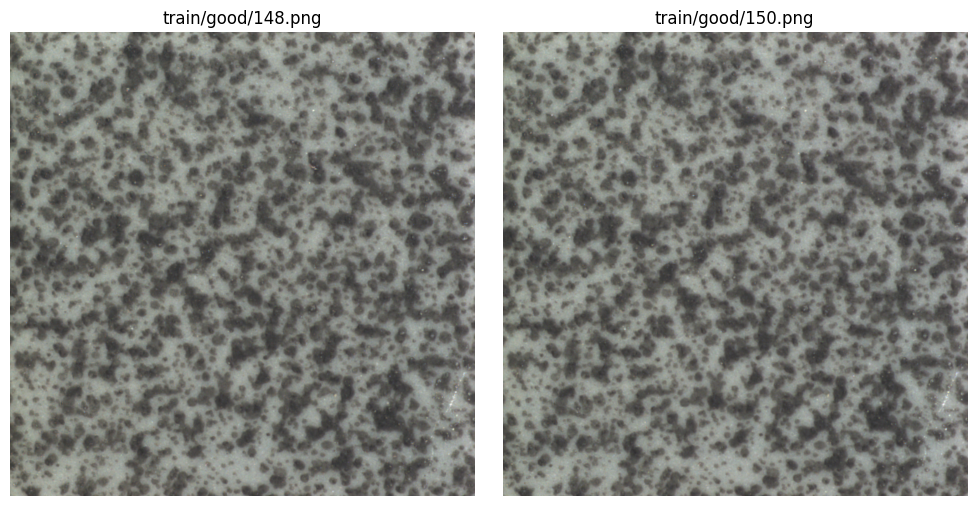

In [10]:
if not near_duplicates.empty:
    for pair in near_duplicates.itertuples(index=False):
        left_row = metadata.loc[metadata["relative_path"] == pair.left_path].iloc[0]
        right_row = metadata.loc[metadata["relative_path"] == pair.right_path].iloc[0]
        left_pixels = np.asarray(Image.open(left_row["source_path"]).convert("RGB"), dtype=np.float32)
        right_pixels = np.asarray(Image.open(right_row["source_path"]).convert("RGB"), dtype=np.float32)
        difference = left_pixels - right_pixels
        print(
            f"{pair.left_path} <-> {pair.right_path}: "
            f"MAE={np.abs(difference).mean():.4f}, "
            f"RMSE={np.sqrt(np.mean(difference ** 2)):.4f}, "
            f"correlation={np.corrcoef(left_pixels.ravel(), right_pixels.ravel())[0, 1]:.6f}"
        )
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(left_pixels.astype(np.uint8))
        axes[0].set_title(pair.left_path)
        axes[1].imshow(right_pixels.astype(np.uint8))
        axes[1].set_title(pair.right_path)
        for axis in axes:
            axis.axis("off")
        plt.tight_layout()
        plt.show()

## 5. Create leakage-safe stratified groups

Near-duplicate candidates are connected into groups. Each group is assigned as one unit, ensuring that similar source images cannot cross split boundaries.

In [11]:
class UnionFind:
    def __init__(self, items):
        self.parent = {item: item for item in items}

    def find(self, item):
        if self.parent[item] != item:
            self.parent[item] = self.find(self.parent[item])
        return self.parent[item]

    def union(self, left, right):
        left_root, right_root = self.find(left), self.find(right)
        if left_root != right_root:
            self.parent[right_root] = left_root


union_find = UnionFind(metadata["relative_path"])
for pair in near_duplicate_pairs:
    union_find.union(pair["left_path"], pair["right_path"])

metadata["group_id"] = metadata["relative_path"].map(union_find.find)
mixed_groups = metadata.groupby("group_id")["defect_type"].nunique()
if mixed_groups.max() != 1:
    raise ValueError("A similarity group contains multiple defect types.")

group_sizes = metadata.groupby("group_id").size()
print(f"Similarity groups: {len(group_sizes)}")
print(f"Largest group size: {group_sizes.max()}")

Similarity groups: 346
Largest group size: 2


## 6. Stratified 70/15/15 split

A deterministic group-aware allocator works within each defect type. Integer targets use the largest-remainder method; groups are assigned to the split with the greatest remaining capacity. This preserves detailed defect representation while keeping similarity groups intact.

In [12]:
SPLIT_NAMES = list(SPLIT_RATIOS)
ratio_array = np.array([SPLIT_RATIOS[name] for name in SPLIT_NAMES])


def integer_targets(total: int) -> dict[str, int]:
    raw = ratio_array * total
    targets = np.floor(raw).astype(int)
    remainder = total - targets.sum()
    fractional_order = np.argsort(-(raw - targets), kind="stable")
    for index in fractional_order[:remainder]:
        targets[index] += 1
    return dict(zip(SPLIT_NAMES, targets))


def assign_groups_for_stratum(frame: pd.DataFrame, seed: int) -> dict[str, str]:
    group_counts = frame.groupby("group_id").size().to_dict()
    targets = integer_targets(len(frame))
    remaining = targets.copy()
    rng = random.Random(seed)
    groups = list(group_counts)
    rng.shuffle(groups)
    groups.sort(key=lambda group: group_counts[group], reverse=True)

    assignment = {}
    for group in groups:
        size = group_counts[group]
        feasible = [name for name in SPLIT_NAMES if remaining[name] >= size]
        candidates = feasible or SPLIT_NAMES
        selected = max(candidates, key=lambda name: (remaining[name], -SPLIT_NAMES.index(name)))
        assignment[group] = selected
        remaining[selected] -= size
    return assignment


group_assignment = {}
for offset, defect_type in enumerate(sorted(metadata["defect_type"].unique())):
    stratum = metadata.loc[metadata["defect_type"] == defect_type]
    group_assignment.update(assign_groups_for_stratum(stratum, SEED + offset))

split_metadata = metadata.copy()
split_metadata["split"] = split_metadata["group_id"].map(group_assignment)

assert split_metadata["split"].notna().all()
assert split_metadata["relative_path"].is_unique
assert split_metadata.groupby("group_id")["split"].nunique().max() == 1
assert split_metadata.groupby("sha256")["split"].nunique().max() == 1
assert not pd.crosstab(split_metadata["split"], split_metadata["binary_class"]).eq(0).any().any()
assert not pd.crosstab(split_metadata["split"], split_metadata["defect_type"]).eq(0).any().any()

split_summary = pd.crosstab(
    [split_metadata["split"], split_metadata["binary_class"]],
    split_metadata["defect_type"],
    margins=True,
)
display(split_summary)

ratio_summary = (
    split_metadata["split"].value_counts()
    .reindex(SPLIT_NAMES)
    .rename("image_count")
    .to_frame()
)
ratio_summary["percentage"] = (ratio_summary["image_count"] / len(split_metadata) * 100).round(2)
display(ratio_summary)

if not near_duplicates.empty:
    display(split_metadata.loc[
        split_metadata["relative_path"].isin(
            set(near_duplicates["left_path"]) | set(near_duplicates["right_path"])
        ),
        ["relative_path", "binary_class", "group_id", "split"],
    ])

defect_type              crack  glue_strip  good  gray_stroke  oil  rough  All
split      binary_class                                                       
test       defective         2           3     0            2    3      2   12
           good              0           0    39            0    0      0   39
train      defective        12          12     0           11   12     11   58
           good              0           0   184            0    0      0  184
validation defective         3           3     0            3    3      2   14
           good              0           0    40            0    0      0   40
All                         17          18   263           16   18     15  347

,image_count,percentage
split,,
train,242,69.74
validation,54,15.56
test,51,14.70


,relative_path,binary_class,group_id,split
265,train/good/148.png,good,train/good/148.png,train
267,train/good/150.png,good,train/good/148.png,train


## 7. EDA summaries and saved artifacts

The manifests define the dataset without copying images. All generated artifacts are stored outside the raw-data directory.

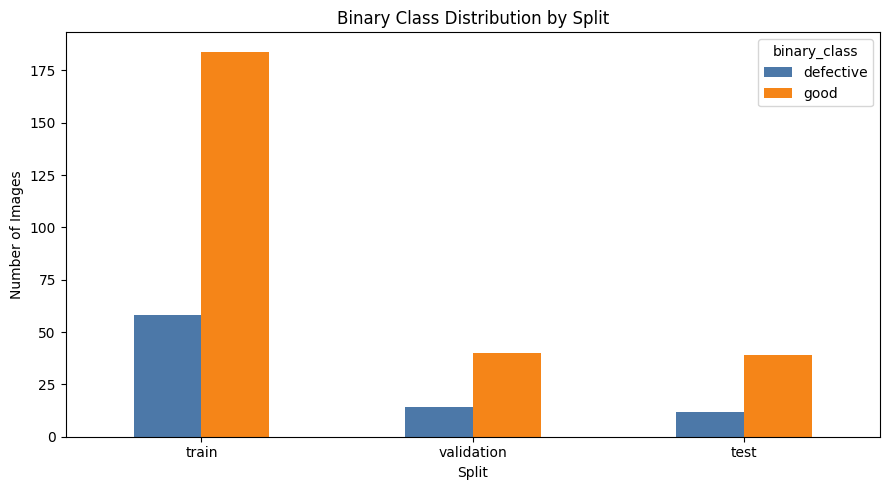

Saved artifacts:
  - D:\Final Project\data\processed\tile\manifests\tile_image_metadata.csv
  - D:\Final Project\data\processed\tile\manifests\tile_supervised_splits.csv
  - D:\Final Project\data\processed\tile\manifests\tile_split_summary.csv
  - D:\Final Project\data\processed\tile\manifests\tile_quality_report.json
  - D:\Final Project\outputs\figures\milestone1\class_distribution_by_split.png


In [13]:
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

metadata_path = MANIFEST_DIR / "tile_image_metadata.csv"
splits_path = MANIFEST_DIR / "tile_supervised_splits.csv"
split_summary_path = MANIFEST_DIR / "tile_split_summary.csv"
quality_report_path = MANIFEST_DIR / "tile_quality_report.json"

metadata.to_csv(metadata_path, index=False)
split_metadata.to_csv(splits_path, index=False)
ratio_summary.to_csv(split_summary_path)

quality_report = {
    "dataset": "MVTec AD",
    "category": "tile",
    "source_images": int(len(metadata)),
    "unreadable_images": len(unreadable_records),
    "exact_duplicate_groups": int(len(exact_duplicate_groups)),
    "near_duplicate_candidates": int(len(near_duplicates)),
    "cross_class_near_duplicate_candidates": (
        int(near_duplicates["cross_class"].sum()) if not near_duplicates.empty else 0
    ),
    "seed": SEED,
    "target_split_ratios": SPLIT_RATIOS,
    "achieved_split_counts": {
        key: int(value) for key, value in split_metadata["split"].value_counts().items()
    },
}
quality_report_path.write_text(json.dumps(quality_report, indent=2), encoding="utf-8")

class_counts = pd.crosstab(split_metadata["split"], split_metadata["binary_class"]).reindex(SPLIT_NAMES)
axis = class_counts.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#F58518"])
axis.set_title("Binary Class Distribution by Split")
axis.set_xlabel("Split")
axis.set_ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
figure_path = FIGURE_DIR / "class_distribution_by_split.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved artifacts:")
for path in (metadata_path, splits_path, split_summary_path, quality_report_path, figure_path):
    print(f"  - {path}")

## 8. Final integrity checks and conclusions

In [14]:
loaded_splits = pd.read_csv(splits_path)
assert len(loaded_splits) == 347
assert loaded_splits["relative_path"].nunique() == 347
assert set(loaded_splits["split"]) == set(SPLIT_NAMES)
assert loaded_splits.groupby("group_id")["split"].nunique().max() == 1
assert loaded_splits.groupby("sha256")["split"].nunique().max() == 1

print("All final integrity checks passed.")
print("The raw dataset was not modified.")
print("The test manifest is now reserved for final model evaluation.")

All final integrity checks passed.
The raw dataset was not modified.
The test manifest is now reserved for final model evaluation.


## Conclusions

- The MVTec AD Tile structure was validated.
- All 347 source images were checked for readability and consistency.
- Exact duplicate and perceptual near-duplicate checks were completed.
- Similarity groups were kept within a single split.
- Reproducible, stratified manifests were created without modifying raw data.
- The official MVTec split was replaced solely for this supervised classification project; results are not directly comparable with the official anomaly-detection benchmark.

### Next milestone

Build and smoke-test a simple custom CNN using the fixed manifests. Augmentation must be applied only to the training pipeline, while model selection and confidence thresholds must use validation data only.

## References

1. MVTec Software GmbH. *MVTec Anomaly Detection Dataset (MVTec AD).* https://www.mvtec.com/research-teaching/datasets/mvtec-ad
2. Bergmann, P., Fauser, M., Sattlegger, D., & Steger, C. (2019). *MVTec AD — A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection.* CVPR.